# CVAE para predecir la masa en el dataset del CERN

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jorobledo/apbf/blob/main/APBF/teorico_practicos/Semana05_CVAE_CERN.ipynb)

En esta notebook vamos a entrenar un **autoencoder variacional condicional (CVAE)** sobre el [dataset de colisiones de electrones del CERN](https://www.kaggle.com/datasets/fedesoriano/cern-electron-collision-data/data).

Objetivo:

- usar las variables cinemáticas medidas como **condición**;
- modelar la distribución condicional de la masa `M`;
- usar el modelo luego para **predecir la masa** a partir del resto de variables;
- obtener una predicción puntual de masa para cada muestra de `z`;
- estimar una noción de dispersión repitiendo el muestreo latente.

La idea del CVAE en este caso es aprender una distribución:

$$
p(M \mid x),
$$

donde `x` representa todas las variables excepto la masa.


## Librerías necesarias

La notebook usa `kagglehub`, `pandas`, `numpy`, `torch`, `matplotlib` y `scikit-learn`.

Si hace falta, se pueden instalar así:

```python
# !pip install kagglehub pandas numpy matplotlib scikit-learn
# !pip install torch torchvision torchaudio
```


In [88]:
import math

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from torch.utils.data import DataLoader, TensorDataset

SEED = 70
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo:", DEVICE)
print("Torch:", torch.__version__)

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.grid"] = True


Dispositivo: cpu
Torch: 2.5.1


## Parte 1

### Carga y limpieza del dataset

El dataset trae eventos de colisiones con variables cinemáticas de dos electrones y la masa invariante `M`.

En esta notebook:

- descartamos `Run` y `Event` porque son identificadores, no variables físicas útiles para el modelo;
- corregimos espacios extra en algunos nombres de columna;
- dejamos `M` como variable objetivo.


In [89]:
path = kagglehub.dataset_download("fedesoriano/cern-electron-collision-data")
print("Path to dataset files:", path)

df = pd.read_csv(path + "/dielectron.csv")
df.columns = df.columns.str.strip()
df = df.drop(columns=["Run", "Event"])

print(df.shape)
df.head()


Path to dataset files: /Users/robledo/.cache/kagglehub/datasets/fedesoriano/cern-electron-collision-data/versions/1
(100000, 17)


,E1,px1,py1,pz1,pt1,eta1,phi1,Q1,E2,px2,py2,pz2,pt2,eta2,phi2,Q2,M
0,58.71410,-7.31132,10.531000,-57.29740,12.82020,-2.20267,2.17766,1,11.2836,-1.032340,-1.88066,-11.0778,2.14537,-2.344030,-2.072810,-1,8.94841
1,6.61188,-4.15213,-0.579855,-5.11278,4.19242,-1.02842,-3.00284,-1,17.1492,-11.713500,5.04474,11.4647,12.75360,0.808077,2.734920,1,15.89300
2,25.54190,-11.48090,2.041680,22.72460,11.66100,1.42048,2.96560,1,15.8203,-1.472800,2.25895,-15.5888,2.69667,-2.455080,2.148570,1,38.38770
3,65.39590,7.51214,11.887100,63.86620,14.06190,2.21838,1.00721,1,25.1273,4.087860,2.59641,24.6563,4.84272,2.330210,0.565865,-1,3.72862
4,61.45040,2.95284,-14.622700,-59.61210,14.91790,-2.09375,-1.37154,-1,13.8871,-0.277757,-2.42560,-13.6708,2.44145,-2.423700,-1.684810,-1,2.74718


In [90]:
print("Columnas:")
print(df.columns.tolist())

print("\nResumen estadístico:")
display(df.describe())


Columnas:
['E1', 'px1', 'py1', 'pz1', 'pt1', 'eta1', 'phi1', 'Q1', 'E2', 'px2', 'py2', 'pz2', 'pt2', 'eta2', 'phi2', 'Q2', 'M']

Resumen estadístico:


,E1,px1,py1,pz1,pt1,eta1,phi1,Q1,E2,px2,py2,pz2,pt2,eta2,phi2,Q2,M
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,99915.000000
mean,36.436466,0.135897,0.182291,-1.508037,14.412167,-0.064095,0.021614,-0.00548,44.002901,-0.003984,0.124654,-1.590559,13.802036,-0.072830,0.021385,-0.004220,30.019521
std,41.216203,13.404976,13.470281,51.603652,12.388740,1.462137,1.799562,0.99999,46.751132,13.127404,13.168867,61.430040,12.460549,1.738033,1.817031,0.999996,25.255847
min,0.377928,-250.587000,-126.079000,-840.987000,0.219629,-4.165380,-3.141580,-1.00000,0.472500,-233.730000,-145.651000,-655.396000,0.026651,-7.064790,-3.141580,-1.000000,2.000080
25%,8.458595,-5.233675,-5.276248,-15.859825,3.771172,-1.283883,-1.527030,-1.00000,11.055725,-4.794770,-4.605965,-22.036950,3.738103,-1.892287,-1.556925,-1.000000,12.445200
50%,21.717000,0.141339,0.099092,-0.312987,12.967800,-0.061178,0.034324,-1.00000,25.264600,-0.035638,0.083665,-0.690244,11.690950,-0.135911,0.026986,-1.000000,21.283100
75%,50.003350,5.714560,5.648087,13.212650,20.018925,1.144408,1.562355,1.00000,66.925525,4.819540,5.061860,19.005825,19.596400,1.768253,1.596737,1.000000,39.025050
max,850.602000,134.539000,147.467000,760.096000,265.578000,2.622970,3.141420,1.00000,948.375000,227.330000,166.283000,935.558000,281.654000,3.060550,3.141290,1.000000,109.999000


In [91]:
df.dropna(inplace=True)

## Parte 2

### Separación entre variables de entrada y masa objetivo

Vamos a usar:

- `X`: todas las variables excepto `M`;
- `y`: la masa `M`.

También tomamos un subconjunto opcional para que la notebook sea más rápida de correr. Si querés máxima calidad, se puede subir `MAX_SAMPLES` o usar todo el dataset.


In [92]:
MAX_SAMPLES = None

if MAX_SAMPLES is not None and MAX_SAMPLES < len(df):
    df_model = df.sample(n=MAX_SAMPLES, random_state=SEED).reset_index(drop=True)
else:
    df_model = df.copy()

target_col = "M"
feature_cols = [c for c in df_model.columns if c != target_col]

X = df_model[feature_cols].to_numpy(dtype=np.float32)
y = df_model[[target_col]].to_numpy(dtype=np.float32)

print("Cantidad de variables de entrada:", len(feature_cols))
print("Shape X:", X.shape)
print("Shape y:", y.shape)


Cantidad de variables de entrada: 16
Shape X: (99915, 16)
Shape y: (99915, 1)


## Parte 3

### Train / validation / test y estandarización

La estandarización es importante porque las variables tienen escalas muy distintas.

Vamos a:

1. separar en entrenamiento, validación y prueba;
2. calcular media y desvío estándar solo con entrenamiento;
3. estandarizar entradas y masa con esas estadísticas.


In [93]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=SEED)
X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=SEED)

x_mean = X_train.mean(axis=0, keepdims=True)
x_std = X_train.std(axis=0, keepdims=True)
x_std = np.where(x_std < 1e-6, 1.0, x_std)

y_mean = y_train.mean(axis=0, keepdims=True)
y_std = y_train.std(axis=0, keepdims=True)
y_std = np.where(y_std < 1e-6, 1.0, y_std)

X_train_std = (X_train - x_mean) / x_std
X_valid_std = (X_valid - x_mean) / x_std
X_test_std = (X_test - x_mean) / x_std

y_train_std = (y_train - y_mean) / y_std
y_valid_std = (y_valid - y_mean) / y_std
y_test_std = (y_test - y_mean) / y_std

print("Train:", X_train_std.shape, y_train_std.shape)
print("Valid:", X_valid_std.shape, y_valid_std.shape)
print("Test: ", X_test_std.shape, y_test_std.shape)


Train: (69940, 16) (69940, 1)
Valid: (14987, 16) (14987, 1)
Test:  (14988, 16) (14988, 1)


In [94]:
BATCH_SIZE = 128

train_dataset = TensorDataset(
    torch.tensor(X_train_std, dtype=torch.float32),
    torch.tensor(y_train_std, dtype=torch.float32),
)
valid_dataset = TensorDataset(
    torch.tensor(X_valid_std, dtype=torch.float32),
    torch.tensor(y_valid_std, dtype=torch.float32),
)
test_dataset = TensorDataset(
    torch.tensor(X_test_std, dtype=torch.float32),
    torch.tensor(y_test_std, dtype=torch.float32),
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


## Parte 4

### Modelo: Conditional VAE para masa

La estructura será:

- **encoder**: recibe `[M, x]` y produce `mu` y `logvar` del latente `z`;
- **decoder**: recibe `[z, x]` y produce una reconstrucción puntual de la masa.

En vez de reconstruir una imagen o un vector grande, acá reconstruimos una sola cantidad escalar: la masa.

La única fuente de aleatoriedad del modelo será el muestreo del latente `z`. El decoder ya no va a predecir una varianza extra para la salida.


In [95]:
class MLP(nn.Module):
    def __init__(self, in_features, out_features, hidden_features=(128, 128), activation=nn.SiLU):
        super().__init__()
        dims = [in_features, *hidden_features, out_features]
        layers = []
        for din, dout in zip(dims[:-2], dims[1:-1]):
            layers.append(nn.Linear(din, dout))
            layers.append(activation())
        layers.append(nn.Linear(dims[-2], dims[-1]))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class ConditionalVAE(nn.Module):
    def __init__(self, condition_dim, latent_dim=8, hidden_features=(128, 128)):
        super().__init__()
        self.condition_dim = condition_dim
        self.latent_dim = latent_dim

        self.encoder = MLP(1 + condition_dim, 2 * latent_dim, hidden_features=hidden_features)
        self.decoder = MLP(latent_dim + condition_dim, 1, hidden_features=hidden_features)

    def encode(self, y, x_cond):
        h = self.encoder(torch.cat([y, x_cond], dim=1))
        mu, logvar = h.chunk(2, dim=1)
        logvar = logvar.clamp(-6.0, 3.0)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, x_cond):
        return self.decoder(torch.cat([z, x_cond], dim=1))

    def forward(self, y, x_cond):
        mu, logvar = self.encode(y, x_cond)
        z = self.reparameterize(mu, logvar)
        y_hat = self.decode(z, x_cond)
        return y_hat, mu, logvar


def cvae_loss(y_true, y_hat, mu, logvar, beta=1.0):
    recon = F.mse_loss(y_hat, y_true)
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1).mean()
    total = recon + beta * kl
    return total, recon, kl


## Parte 5

### Entrenamiento

Usamos una versión simple del entrenamiento variacional:

- pérdida de reconstrucción puntual sobre la masa estandarizada;
- término KL para regularizar el latente;
- un `beta` pequeño al comienzo para no forzar demasiado rápido la regularización.


In [96]:
def beta_schedule(epoch, total_epochs, beta_max=0.2, warmup_epochs=15):
    if epoch <= 1:
        return 0.01
    if epoch >= warmup_epochs:
        return beta_max
    progress = (epoch - 1) / max(1, warmup_epochs - 1)
    return 0.01 + progress * (beta_max - 0.01)


def train_cvae(model, train_loader, valid_loader, epochs=60, lr=0.8e-3):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train_total": [], "valid_total": [], "valid_recon": [], "valid_kl": []}

    for epoch in range(1, epochs + 1):
        beta = beta_schedule(epoch, epochs, beta_max=0.2, warmup_epochs=15)
        model.train()
        total = 0.0

        for x_cond, y_true in train_loader:
            x_cond = x_cond.to(DEVICE)
            y_true = y_true.to(DEVICE)

            y_hat, mu, logvar = model(y_true, x_cond)
            loss, recon, kl = cvae_loss(y_true, y_hat, mu, logvar, beta=beta)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total += loss.item() * x_cond.size(0)

        history["train_total"].append(total / len(train_loader.dataset))

        model.eval()
        total = 0.0
        recon_total = 0.0
        kl_total = 0.0

        with torch.no_grad():
            for x_cond, y_true in valid_loader:
                x_cond = x_cond.to(DEVICE)
                y_true = y_true.to(DEVICE)
                y_hat, mu, logvar = model(y_true, x_cond)
                loss, recon, kl = cvae_loss(y_true, y_hat, mu, logvar, beta=beta)

                total += loss.item() * x_cond.size(0)
                recon_total += recon.item() * x_cond.size(0)
                kl_total += kl.item() * x_cond.size(0)

        n_valid = len(valid_loader.dataset)
        history["valid_total"].append(total / n_valid)
        history["valid_recon"].append(recon_total / n_valid)
        history["valid_kl"].append(kl_total / n_valid)

        if epoch % 5 == 0 or epoch == 1:
            print(
                f"epoch={epoch:03d}  beta={beta:.3f}  "
                f"train={history['train_total'][-1]:.4f}  "
                f"valid={history['valid_total'][-1]:.4f}"
            )

    return history


model = ConditionalVAE(condition_dim=X_train_std.shape[1], latent_dim=16, hidden_features=(128, 128))
history = train_cvae(model, train_loader, valid_loader, epochs=60, lr=0.8e-3)


epoch=001  beta=0.010  train=0.1129  valid=0.0432
epoch=005  beta=0.064  train=0.0322  valid=0.0248
epoch=010  beta=0.132  train=0.0082  valid=0.0081
epoch=015  beta=0.200  train=0.0049  valid=0.0051
epoch=020  beta=0.200  train=0.0036  valid=0.0067
epoch=025  beta=0.200  train=0.0027  valid=0.0027
epoch=030  beta=0.200  train=0.0021  valid=0.0034
epoch=035  beta=0.200  train=0.0019  valid=0.0025
epoch=040  beta=0.200  train=0.0017  valid=0.0017
epoch=045  beta=0.200  train=0.0016  valid=0.0020
epoch=050  beta=0.200  train=0.0013  valid=0.0018
epoch=055  beta=0.200  train=0.0011  valid=0.0011
epoch=060  beta=0.200  train=0.0012  valid=0.0011


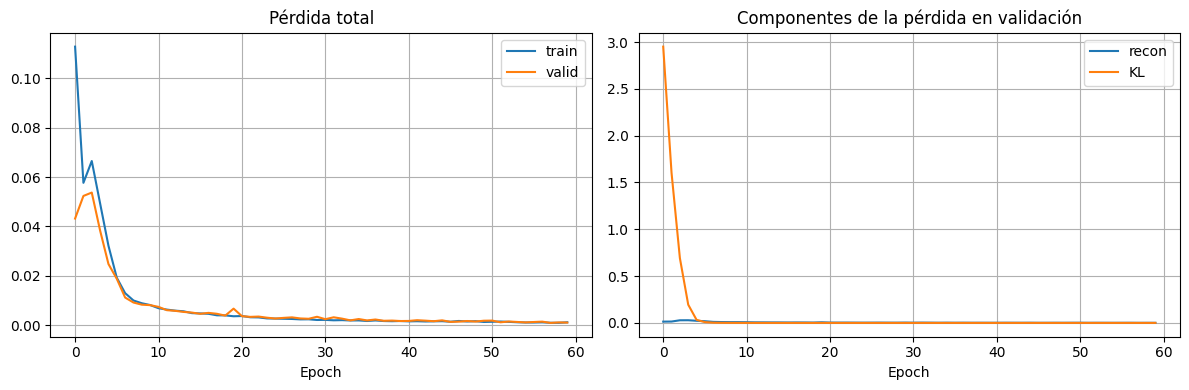

In [97]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["train_total"], label="train")
axes[0].plot(history["valid_total"], label="valid")
axes[0].set_title("Pérdida total")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["valid_recon"], label="recon")
axes[1].plot(history["valid_kl"], label="KL")
axes[1].set_title("Componentes de la pérdida en validación")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()


## Parte 6

### Baseline: regresión lineal

Antes de evaluar el CVAE conviene compararlo contra un modelo mucho más simple.

La regresión lineal sirve como baseline porque:

- es rápida de entrenar;
- sus coeficientes son fáciles de interpretar;
- nos dice cuánto de la masa puede explicarse con una relación aproximadamente lineal entre las variables.

Si el CVAE no mejora de forma clara a esta baseline, entonces su mayor complejidad no estaría justificada para la tarea de predicción puntual.


In [98]:
linear_reg = LinearRegression()
linear_reg.fit(X_train_std, y_train_std.ravel())

lin_pred_std = linear_reg.predict(X_test_std).reshape(-1, 1)
lin_pred = lin_pred_std * y_std + y_mean

lin_mae = mean_absolute_error(y_test, lin_pred)
lin_rmse = math.sqrt(mean_squared_error(y_test, lin_pred))
lin_r2 = r2_score(y_test, lin_pred)

print(f"Regresión lineal | MAE  = {lin_mae:.4f}")
print(f"Regresión lineal | RMSE = {lin_rmse:.4f}")
print(f"Regresión lineal | R2   = {lin_r2:.4f}")


Regresión lineal | MAE  = 14.3357
Regresión lineal | RMSE = 19.6205
Regresión lineal | R2   = 0.3952


## Parte 7

### Predicción de masa con el CVAE

Una vez entrenado el CVAE, ya no usamos la masa verdadera.

En inferencia:

- tomamos solo la condición `x`;
- muestreamos `z ~ N(0, I)` desde el prior;
- el decoder produce una masa puntual para cada muestra de `z`.

Si repetimos esto varias veces, podemos estimar:

- una **predicción media** de la masa;
- una **desviación estándar entre muestras latentes** como medida de dispersión.

Estas cantidades se comparan luego con la regresión lineal entrenada sobre los mismos datos.


In [99]:
@torch.no_grad()
def predict_mass_distribution(model, x_cond, n_samples=100):
    model.eval()
    x_cond = x_cond.to(DEVICE)
    draws = []

    for _ in range(n_samples):
        z = torch.randn(x_cond.size(0), model.latent_dim, device=x_cond.device)
        y_hat = model.decode(z, x_cond)
        draws.append(y_hat)

    draws = torch.stack(draws, dim=0)
    pred_mean = draws.mean(dim=0)
    pred_std = draws.std(dim=0)
    return pred_mean, pred_std, draws


x_test_tensor = torch.tensor(X_test_std, dtype=torch.float32)
pred_mean_std, pred_std_std, pred_draws_std = predict_mass_distribution(model, x_test_tensor, n_samples=150)

pred_mean = pred_mean_std.cpu().numpy() * y_std + y_mean
pred_std = pred_std_std.cpu().numpy() * y_std
y_true = y_test

cvae_mae = mean_absolute_error(y_true, pred_mean)
cvae_rmse = math.sqrt(mean_squared_error(y_true, pred_mean))
cvae_r2 = r2_score(y_true, pred_mean)

comparison_df = pd.DataFrame([
    {'modelo': 'Regresión lineal', 'MAE': lin_mae, 'RMSE': lin_rmse, 'R2': lin_r2},
    {'modelo': 'CVAE', 'MAE': cvae_mae, 'RMSE': cvae_rmse, 'R2': cvae_r2},
]).sort_values('MAE')

comparison_df


,modelo,MAE,RMSE,R2
1,CVAE,0.448993,0.714812,0.999197
0,Regresión lineal,14.335706,19.620487,0.395151


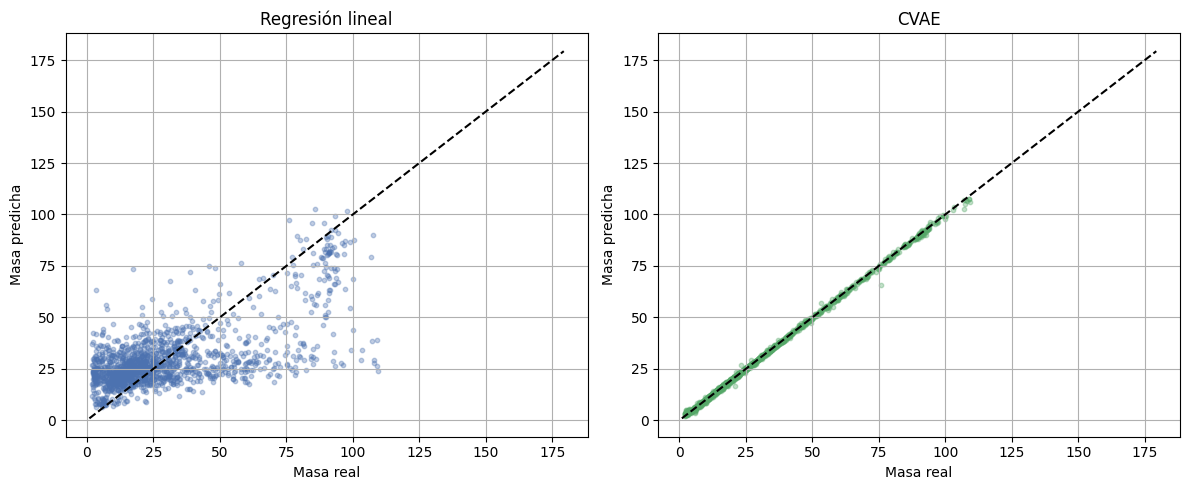

In [100]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

mass_min = float(min(y_true.min(), pred_mean.min(), lin_pred.min()))
mass_max = float(max(y_true.max(), pred_mean.max(), lin_pred.max()))

axes[0].scatter(y_true[:1500], lin_pred[:1500], s=10, alpha=0.35, color='#4C72B0')
axes[0].plot([mass_min, mass_max], [mass_min, mass_max], color='black', linestyle='--')
axes[0].set_xlabel('Masa real')
axes[0].set_ylabel('Masa predicha')
axes[0].set_title('Regresión lineal')

axes[1].scatter(y_true[:1500], pred_mean[:1500], s=10, alpha=0.35, color='#55A868')
axes[1].plot([mass_min, mass_max], [mass_min, mass_max], color='black', linestyle='--')
axes[1].set_xlabel('Masa real')
axes[1].set_ylabel('Masa predicha')
axes[1].set_title('CVAE')

plt.tight_layout()
plt.show()


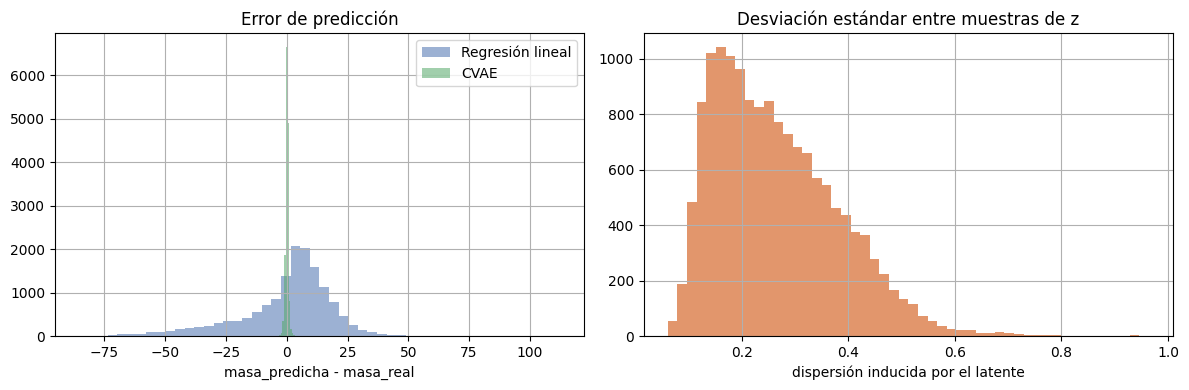

In [101]:
lin_errors = (lin_pred.reshape(-1, 1) - y_true)
cvae_errors = (pred_mean.reshape(-1, 1) - y_true)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(lin_errors, bins=50, color='#4C72B0', alpha=0.55, label='Regresión lineal')
axes[0].hist(cvae_errors, bins=50, color='#55A868', alpha=0.55, label='CVAE')
axes[0].set_title('Error de predicción')
axes[0].set_xlabel('masa_predicha - masa_real')
axes[0].legend()

axes[1].hist(pred_std, bins=50, color='#DD8452', alpha=0.85)
axes[1].set_title('Desviación estándar entre muestras de z')
axes[1].set_xlabel('dispersión inducida por el latente')

plt.tight_layout()
plt.show()


## Parte 8

### Mirar la distribución predictiva en algunos eventos

Una ventaja del CVAE frente a una regresión puramente determinista es que podemos muestrear distintos valores de `z` y obtener varias masas plausibles condicionadas por las mismas variables de entrada.

Abajo elegimos algunos eventos del conjunto de prueba y mostramos la dispersión de masas inducida únicamente por el muestreo latente. También marcamos la predicción de la regresión lineal para comparar una salida determinista contra el abanico de masas que genera el CVAE.


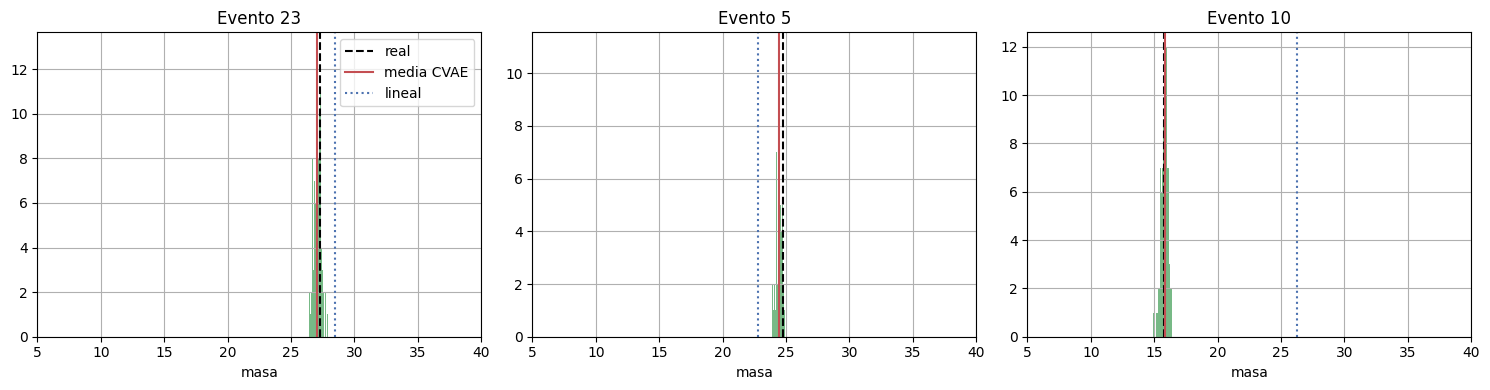

In [102]:
indices = [23, 5, 10]
fig, axes = plt.subplots(1, len(indices), figsize=(15, 4))

draws_np = pred_draws_std.cpu().numpy() * y_std + y_mean

for ax, idx in zip(axes, indices):
    ax.hist(draws_np[:, idx, 0], bins=35, alpha=0.8, color='#55A868')
    ax.axvline(y_true[idx, 0], color='black', linestyle='--', label='real')
    ax.axvline(pred_mean[idx, 0], color='#C44E52', linestyle='-', label='media CVAE')
    ax.axvline(lin_pred[idx, 0], color='#4C72B0', linestyle=':', label='lineal')
    ax.set_title(f'Evento {idx}')
    ax.set_xlabel('masa')
    ax.set_xlim(5, 40)

axes[0].legend()
plt.tight_layout()
plt.show()
